# Quantum Machine Learning (QML) Classifier Project
This notebook is structured for final submission.

In [ ]:
import os
if not os.path.exists('figures'):
    os.makedirs('figures')
print("Folder 'figures' created (or already exists).")

## 1. Introduction
Describe problem, motivation.

## 2. Dataset & Preprocessing

In [ ]:
# Load dataset
import pandas as pd
# df = pd.read_csv('your_file.csv')

In [ ]:
# Cleaning, scaling placeholder

## 3. Classical Baselines

In [ ]:
# Classical models placeholder

## 4. QML Pipeline

In [ ]:
# QML code placeholder

## 5. Training & Tuning

In [ ]:
# Training loops placeholder

## 6. Results & Comparison

In [ ]:
# Plots & tables placeholder

## 7. Extension Dataset

## 8. Conclusion

## Appendix: Original Implementation Code
The following cells contain the complete implementation developed during the project.

In [137]:
import pandas as pd
import numpy as np

# Data splitting & scaling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Classical models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

# Evaluation metrics
from sklearn.metrics import roc_auc_score, accuracy_score

import matplotlib.pyplot as plt
import seaborn as sns

In [138]:
df = pd.read_csv("dataset.csv")
df.head()


,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
0,94.689486,0.212096,2.379196,1.0,0.0,0.0,0.0,0
1,2.148094,3.631258,0.867552,1.0,1.0,0.0,1.0,0
2,8.201513,0.196793,0.568646,1.0,0.0,0.0,1.0,0
3,1.813192,0.613588,0.749469,0.0,1.0,0.0,1.0,0
4,26.211924,4.871637,1.610984,1.0,0.0,1.0,1.0,0


In [139]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 8 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   distance_from_home              99997 non-null   float64
 1   distance_from_last_transaction  99998 non-null   float64
 2   ratio_to_median_purchase_price  99997 non-null   float64
 3   repeat_retailer                 99997 non-null   float64
 4   used_chip                       99998 non-null   float64
 5   used_pin_number                 99997 non-null   float64
 6   online_order                    99995 non-null   float64
 7   fraud                           100000 non-null  int64  
dtypes: float64(7), int64(1)
memory usage: 6.1 MB


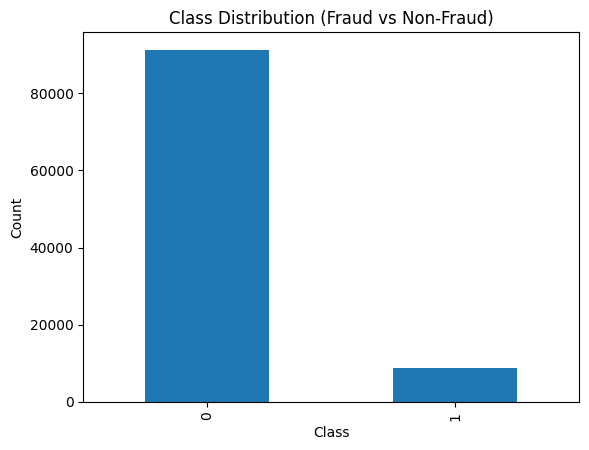

fraud
0    91260
1     8740
Name: count, dtype: int64


In [140]:
fraud_counts = df["fraud"].value_counts()

plt.figure()
fraud_counts.plot(kind="bar")
plt.title("Class Distribution (Fraud vs Non-Fraud)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

print(fraud_counts)

In [141]:

## Missing Values

In [142]:
df.isnull().sum()


,0
distance_from_home,3
distance_from_last_transaction,2
ratio_to_median_purchase_price,3
repeat_retailer,3
used_chip,2
used_pin_number,3
online_order,5
fraud,0


In [143]:
from sklearn.impute import SimpleImputer

In [144]:
X = df.drop("fraud", axis=1)
y = df["fraud"]

In [145]:
imputer = SimpleImputer(strategy="median")
X_imputed = imputer.fit_transform(X)

X_imputed = pd.DataFrame(X_imputed, columns=X.columns)

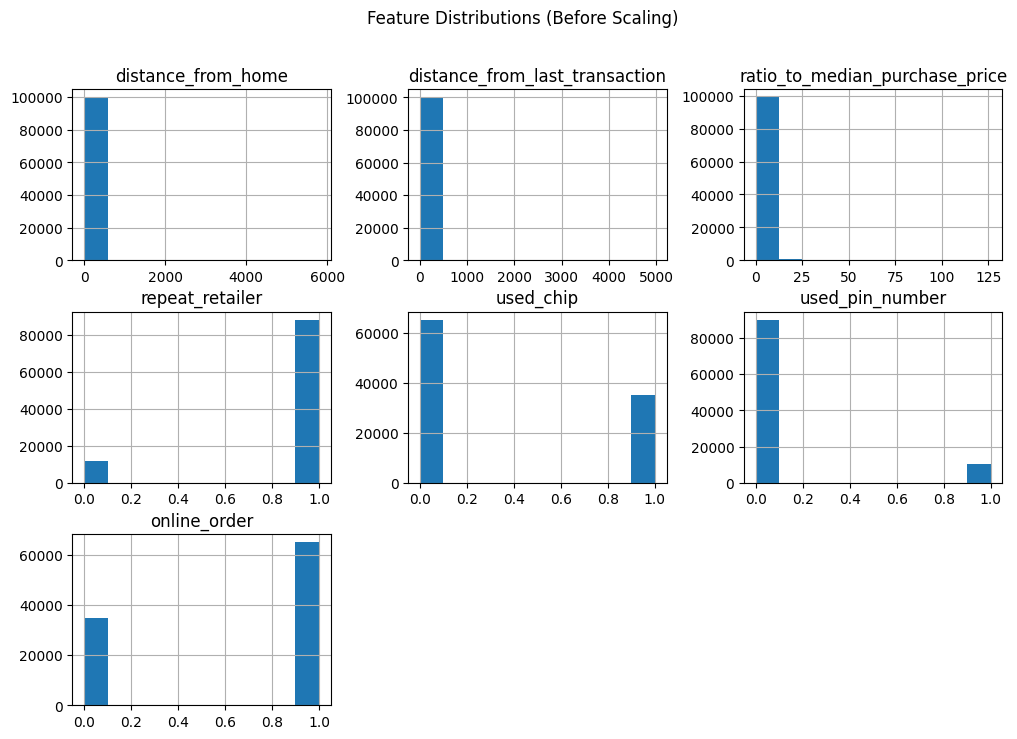

In [146]:
X_imputed.hist(figsize=(12,8))
plt.suptitle("Feature Distributions (Before Scaling)")
plt.show()

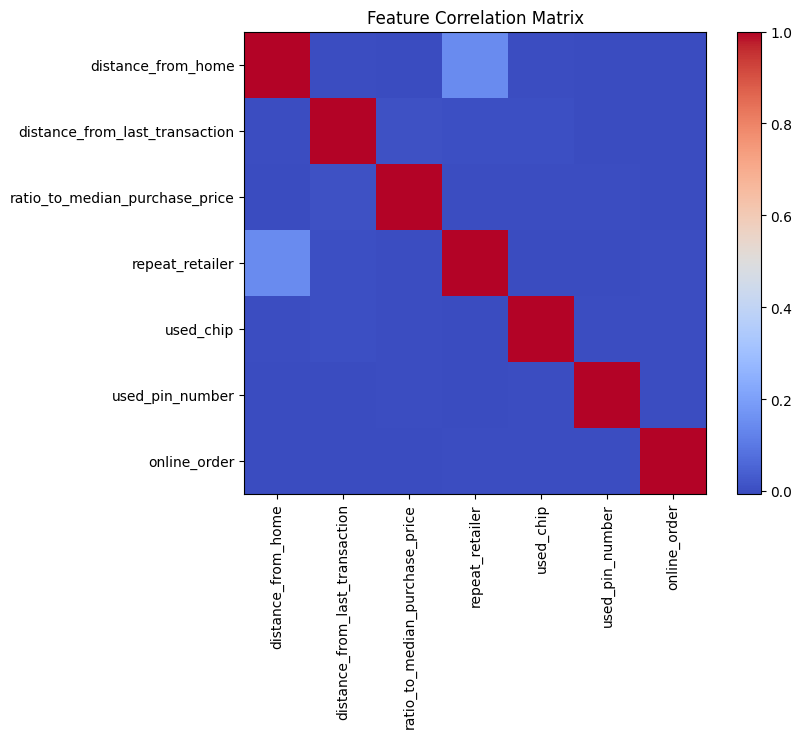

In [147]:
corr = X_imputed.corr()

plt.figure(figsize=(8,6))
plt.imshow(corr, cmap="coolwarm")
plt.colorbar()
plt.xticks(range(len(corr)), corr.columns, rotation=90)
plt.yticks(range(len(corr)), corr.columns)
plt.title("Feature Correlation Matrix")
plt.show()

/tmp/ipython-input-3633029921.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


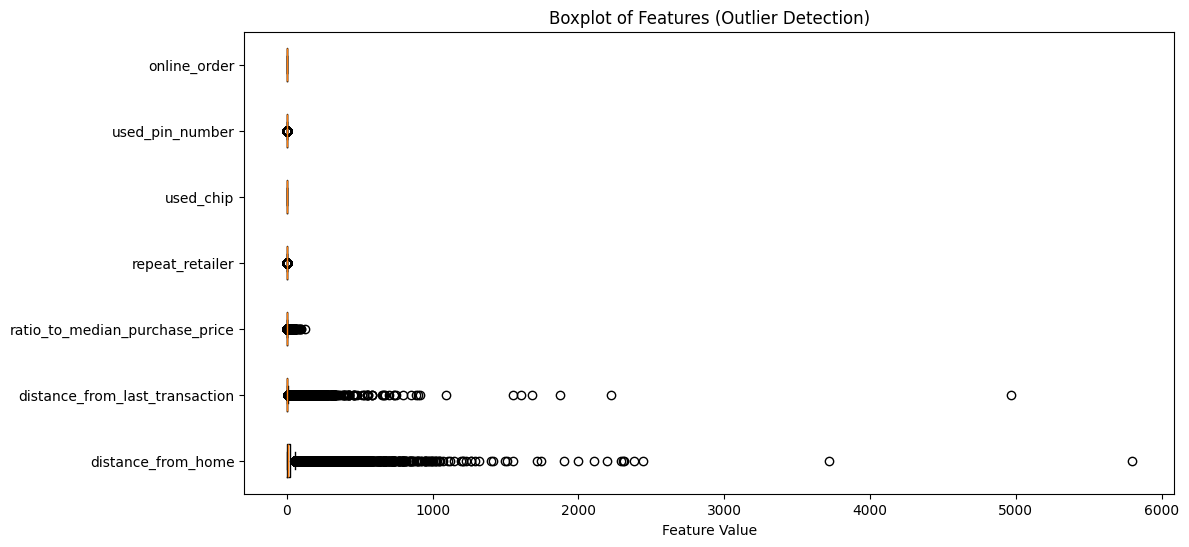

In [148]:
plt.figure(figsize=(12,6))
plt.boxplot(
    [X_imputed[col] for col in X_imputed.columns],
    labels=X_imputed.columns,
    vert=False
)
plt.title("Boxplot of Features (Outlier Detection)")
plt.xlabel("Feature Value")
plt.show()

In [149]:
def detect_outliers_iqr(df):
    outlier_summary = {}
    for col in df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outliers = ((df[col] < lower) | (df[col] > upper)).sum()
        outlier_summary[col] = outliers

    return pd.Series(outlier_summary)

outlier_counts = detect_outliers_iqr(X_imputed)
print(outlier_counts)

distance_from_home                10384
distance_from_last_transaction    12451
ratio_to_median_purchase_price     8430
repeat_retailer                   11943
used_chip                             0
used_pin_number                   10129
online_order                          0
dtype: int64


In [150]:
X_capped = X_imputed.copy()

for col in X_capped.columns:
    Q1 = X_capped[col].quantile(0.25)
    Q3 = X_capped[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    X_capped[col] = X_capped[col].clip(lower, upper)

/tmp/ipython-input-4188019839.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


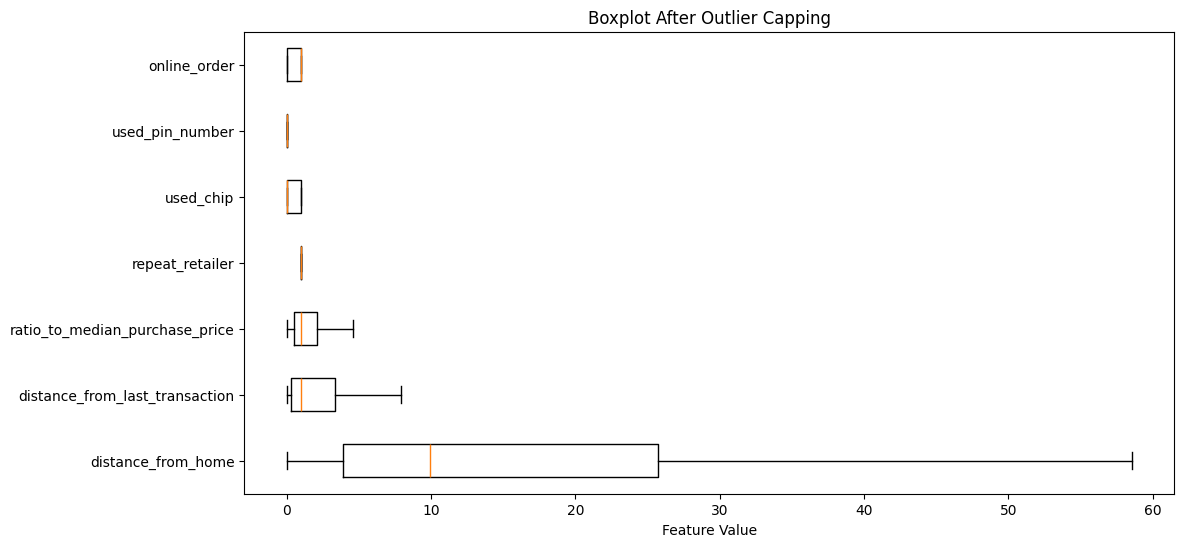

In [151]:
plt.figure(figsize=(12,6))
plt.boxplot(
    [X_capped[col] for col in X_capped.columns],
    labels=X_capped.columns,
    vert=False
)
plt.title("Boxplot After Outlier Capping")
plt.xlabel("Feature Value")
plt.show()


In [152]:
#Feature Scaling

In [153]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_capped)

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

In [154]:
from sklearn.decomposition import PCA


In [155]:
pca = PCA(n_components=4, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print("Explained variance:", pca.explained_variance_ratio_)

Explained variance: [0.2027766  0.20050071 0.19974837 0.19872817]


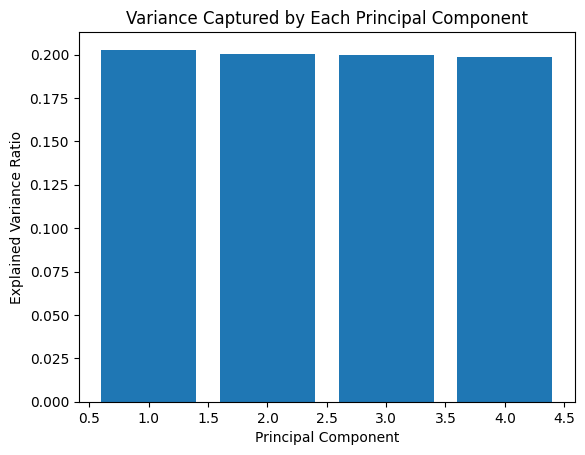

Explained variance per component: [0.2027766  0.20050071 0.19974837 0.19872817]
Total variance retained: 0.801753849410277


In [156]:
plt.figure()
plt.bar(range(1, 5), pca.explained_variance_ratio_)
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Variance Captured by Each Principal Component")
plt.show()

print("Explained variance per component:", pca.explained_variance_ratio_)
print("Total variance retained:", pca.explained_variance_ratio_.sum())

In [157]:
X_final = X_pca
y_final = y.values

print(X_final.shape)  # must be (n_samples, 4)

(100000, 4)


In [158]:
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_final,
    test_size=0.2,
    stratify=y_final,
    random_state=42
)

In [159]:
from collections import Counter

print("Original class distribution:", Counter(y))

Original class distribution: Counter({0: 91260, 1: 8740})


In [160]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)
X_rus, y_rus = rus.fit_resample(X_train, y_train)

print("After undersampling:", Counter(y_rus))

After undersampling: Counter({np.int64(0): 6992, np.int64(1): 6992})


In [161]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_train, y_train)

print("After SMOTE:", Counter(y_smote))

After SMOTE: Counter({np.int64(0): 73008, np.int64(1): 73008})


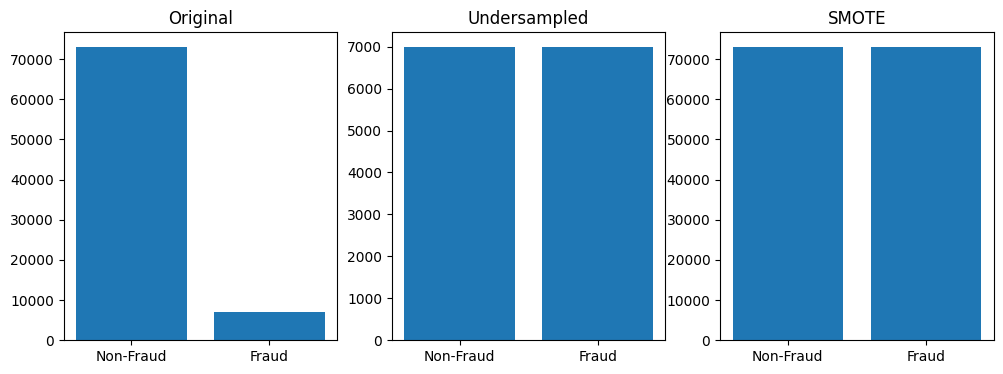

In [162]:
fig, axs = plt.subplots(1, 3, figsize=(12,4))

axs[0].bar(["Non-Fraud", "Fraud"], Counter(y_train).values())
axs[0].set_title("Original")

axs[1].bar(["Non-Fraud", "Fraud"], Counter(y_rus).values())
axs[1].set_title("Undersampled")

axs[2].bar(["Non-Fraud", "Fraud"], Counter(y_smote).values())
axs[2].set_title("SMOTE")

plt.show()

In [163]:
lr = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

lr.fit(X_smote, y_smote)

lr_auc = roc_auc_score(y_test, lr.predict_proba(X_test)[:,1])
print("Logistic AUC:", lr_auc)


Logistic AUC: 0.9107316254110392


Text(0.5, 1.0, 'ROC Curve – Logistic Regression')

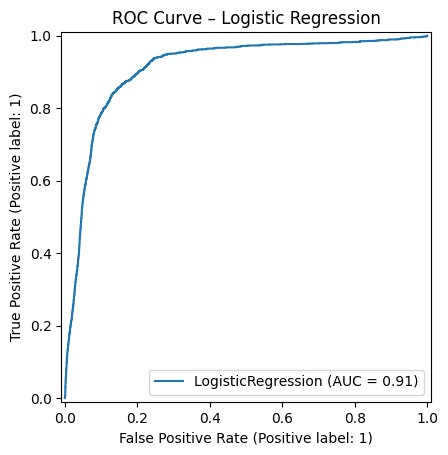

In [164]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(lr, X_test, y_test)
plt.title("ROC Curve – Logistic Regression")

Logistic Accuracy: 0.8393
Logistic Confusion Matrix:
 [[15266  2986]
 [  228  1520]]


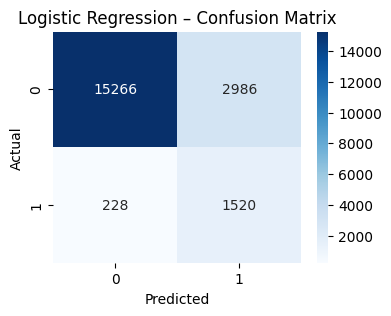

In [165]:
# Predictions
lr_pred = lr.predict(X_test)

# Accuracy
lr_acc = accuracy_score(y_test, lr_pred)
print("Logistic Accuracy:", lr_acc)

# Confusion Matrix
cm_lr = confusion_matrix(y_test, lr_pred)
print("Logistic Confusion Matrix:\n", cm_lr)

# Visualization
plt.figure(figsize=(4,3))
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues")
plt.title("Logistic Regression – Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [166]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    class_weight="balanced",
    random_state=42
)

rf.fit(X_smote, y_smote)

rf_auc = roc_auc_score(y_test, rf.predict_proba(X_test)[:,1])
print("RF AUC:", rf_auc)


RF AUC: 0.9778555975308308


RF Accuracy: 0.9197
RF Confusion Matrix:
 [[16744  1508]
 [   98  1650]]


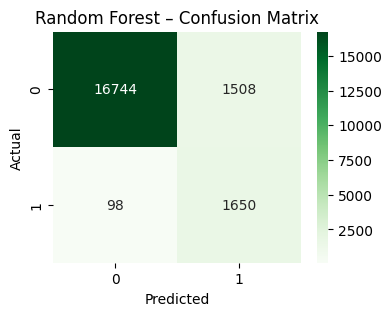

In [167]:
rf_pred = rf.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)
print("RF Accuracy:", rf_acc)

cm_rf = confusion_matrix(y_test, rf_pred)
print("RF Confusion Matrix:\n", cm_rf)

plt.figure(figsize=(4,3))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens")
plt.title("Random Forest – Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Text(0.5, 1.0, 'ROC Curve – Random Forest')

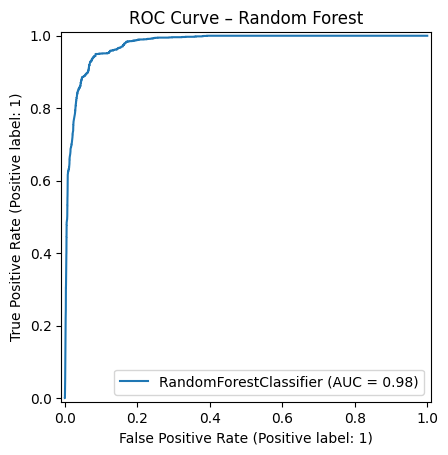

In [168]:
RocCurveDisplay.from_estimator(rf, X_test, y_test)
plt.title("ROC Curve – Random Forest")

In [169]:
mlp= MLPClassifier(
    hidden_layer_sizes=(8,),
    max_iter=500,
    random_state=42
)

mlp.fit(X_smote, y_smote)

mlp_auc = roc_auc_score(y_test, mlp.predict_proba(X_test)[:,1])
print("NN AUC:", mlp_auc)


NN AUC: 0.9804236525159338


Text(0.5, 1.0, 'ROC Curve – MLP')

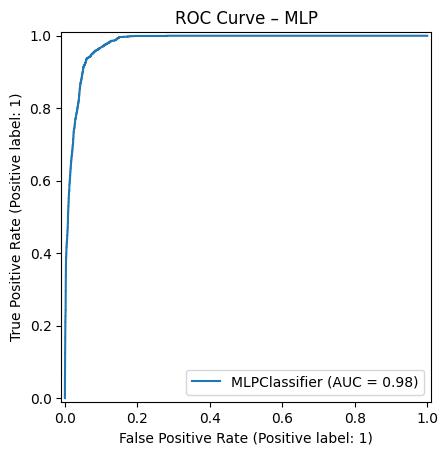

In [170]:
RocCurveDisplay.from_estimator(mlp, X_test, y_test)
plt.title("ROC Curve – MLP")

NN Accuracy: 0.91885
NN Confusion Matrix:
 [[16701  1551]
 [   72  1676]]


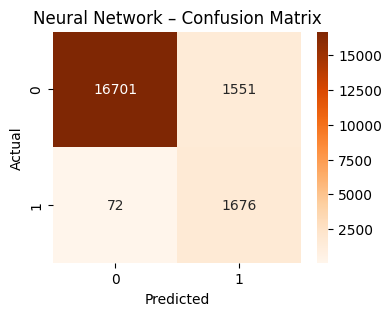

In [171]:
mlp_pred = mlp.predict(X_test)

mlp_acc = accuracy_score(y_test, mlp_pred)
print("NN Accuracy:", mlp_acc)

cm_mlp = confusion_matrix(y_test, mlp_pred)
print("NN Confusion Matrix:\n", cm_mlp)

plt.figure(figsize=(4,3))
sns.heatmap(cm_mlp, annot=True, fmt="d", cmap="Oranges")
plt.title("Neural Network – Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [172]:
results = pd.DataFrame({
    "Model": ["LogReg", "RandomForest", "MLP"],
    "AUC": [lr_auc, rf_auc, mlp_auc]
})
results

,Model,AUC
0,LogReg,0.910732
1,RandomForest,0.977856
2,MLP,0.980424


In [173]:
!pip install qiskit qiskit-aer qiskit-machine-learning qiskit-algorithms


In [174]:
# Quantum simulator
from qiskit_aer import Aer

# Quantum circuit templates
from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes

# Classical optimizer (new Qiskit location)
from qiskit_algorithms.optimizers import COBYLA

# Quantum ML algorithm
from qiskit_machine_learning.algorithms import VQC

# Evaluation
from sklearn.metrics import accuracy_score

from qiskit import QuantumCircuit

In [175]:
import numpy as np
X_train = np.asarray(X_smote)
y_train = np.asarray(y_smote)
X_test  = np.asarray(X_test)
y_test  = np.asarray(y_test)


X_q_train = X_train[:70]
y_q_train = y_train[:70]
X_q_test  = X_test
y_q_test  = y_test

In [176]:
num_qubits = X_qml_train.shape[1]
print("Number of qubits:", num_qubits)


Number of qubits: 4


In [177]:
feature_map = ZZFeatureMap(
    feature_dimension=num_qubits,
    reps=1
)


/tmp/ipython-input-3149562973.py:1: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(


In [178]:
ansatz = RealAmplitudes(
    num_qubits=num_qubits,
    reps=2,
    entanglement="full"
)


/tmp/ipython-input-3264731929.py:1: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(


In [179]:
backend = Aer.get_backend("aer_simulator_statevector")


In [180]:
optimizer = COBYLA(maxiter=100)


In [185]:
vqc = VQC(
    feature_map=feature_map,
    ansatz=ansatz,
    optimizer=optimizer,

)


In [186]:
vqc.fit(X_q_train, y_q_train)

In [187]:
y_pred = vqc.predict(X_q_test)

VQC Accuracy: 0.5881


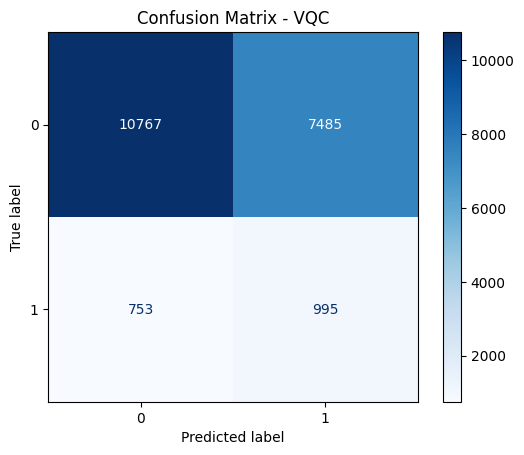

In [188]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

acc = accuracy_score(y_q_test, y_pred)
print("VQC Accuracy:", acc)

cm = confusion_matrix(y_q_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - VQC")
plt.show()


In [189]:
from sklearn.metrics import roc_auc_score, roc_curve

y_prob = vqc.predict_proba(X_q_test)[:, 1]
auc = roc_auc_score(y_q_test, y_prob)
print("AUC Score:", auc)

AUC Score: 0.5928675851829786


In [190]:
comparison = pd.DataFrame({
    "Model": [
        "Variational Quantum Classifier",
        "Logistic Regression",
         "Random Forest",
        "MLP Classifier"
    ],
    "Accuracy": [
        acc,
        lr_acc,
        mlp_acc,
        rf_acc
    ]
})

comparison

,Model,Accuracy
0,Variational Quantum Classifier,0.58810
1,Logistic Regression,0.83930
2,Random Forest,0.91885
3,MLP Classifier,0.91970


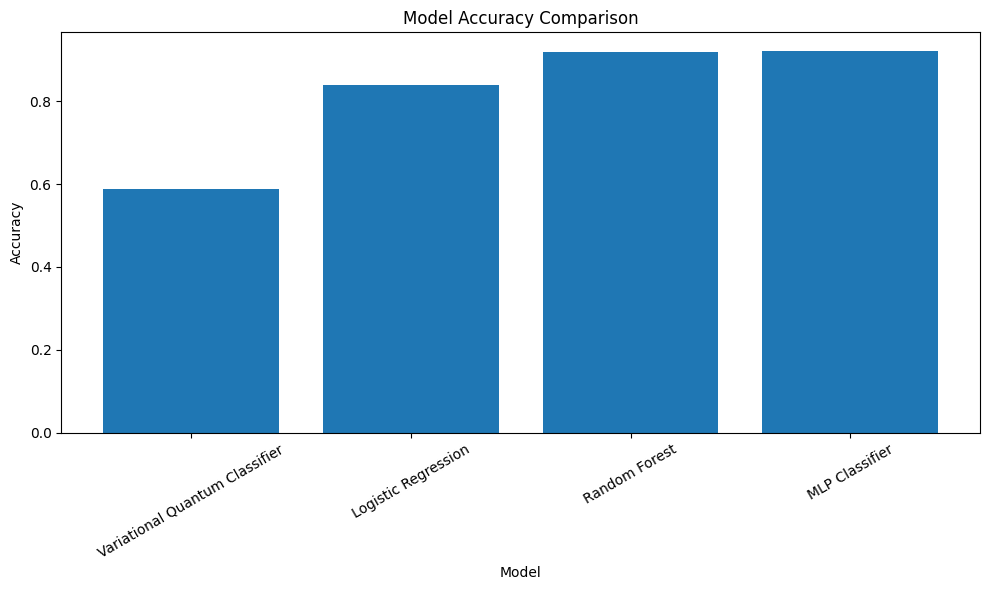

In [191]:

plt.figure(figsize=(10, 6))
plt.bar(comparison["Model"], comparison["Accuracy"])
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()
